# Supervised, unsupervised, self-supervised

The textbook definitions are easy to recite and easy to misapply. This notebook runs
all three on **the same data**, so the difference is something you can see rather than
something you memorise.

The distinction is not about the algorithm. It is about **what signal the model is
asked to reproduce**, and therefore what you needed to collect before you could start.

Handout section 3 covers the taxonomy in full.

## 1. Setup

In [1]:
# pip install numpy==2.4.4 scikit-learn==1.9.0 matplotlib==3.11.1

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, adjusted_rand_score, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

FIGURES = Path("../Figures")
FIGURES.mkdir(exist_ok=True)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11

## 2. One dataset, three questions

The wine dataset holds 13 chemical measurements for 178 wines from three different
cultivars. It is small, entirely numeric, and ships with scikit-learn.

The same table will answer three different questions depending only on what we treat
as the thing to be predicted.

In [2]:
data = load_wine(as_frame=True)
X, y = data.data, data.target
print(f"{X.shape[0]} wines, {X.shape[1]} measurements, {len(np.unique(y))} cultivars")
print(f"features: {', '.join(X.columns[:6])} ...")

178 wines, 13 measurements, 3 cultivars
features: alcohol, malic_acid, ash, alcalinity_of_ash, magnesium, total_phenols ...


## 3. Supervised learning: someone labelled the data

We have the cultivar for every wine, because a person recorded it. The model learns a
mapping from measurements to that label, and we can check its answers against the
truth.

**What it costs:** the labels. Somebody had to produce 178 of them, correctly. In most
real problems this is the expensive part, and often the part that does not exist.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
clf.fit(X_train, y_train)
print(f"classification accuracy: {accuracy_score(y_test, clf.predict(X_test)):.3f}")

classification accuracy: 0.981


Classification predicts a category. Change the target to a continuous quantity and the
same idea becomes **regression** — still supervised, still learning from labels
somebody supplied. Here we predict a wine's colour intensity from its other
measurements.

In [4]:
target_col = "color_intensity"
X_reg = X.drop(columns=[target_col])
y_reg = X[target_col]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=RANDOM_STATE
)
reg = make_pipeline(StandardScaler(), LinearRegression())
reg.fit(Xr_train, yr_train)
print(f"regression R^2: {r2_score(yr_test, reg.predict(Xr_test)):.3f}")

regression R^2: 0.622


## 4. Unsupervised learning: nobody labelled anything

Now we throw the labels away and ask a different question: **does this data fall into
natural groups?** No target, no right answer to check against, no accuracy to report.

k-means partitions the samples into k groups by geometry alone. Note we must tell it
*how many* groups to look for — the algorithm cannot discover that, and choosing k is
a real problem we return to in lesson 8.

In [5]:
scaler = StandardScaler().fit(X)
X_scaled = scaler.transform(X)

kmeans = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE)
clusters = kmeans.fit_predict(X_scaled)

# We happen to hold the true labels, so we can ask - only as a teaching check, never
# as something available in a real unsupervised setting - how well the geometry
# recovered them. 1.0 is a perfect match, 0.0 is chance.
print(f"adjusted Rand index against the true cultivars: {adjusted_rand_score(y, clusters):.3f}")

adjusted Rand index against the true cultivars: 0.897


That score is high, which is a happy accident of this dataset: the chemical groups
really are geometrically separated. **Do not expect it.** Clustering finds structure
in the feature space; whether that structure means anything is a question the
algorithm cannot answer, and often the groups it finds correspond to nothing you care
about.

Let us look at both pictures side by side. We project to two dimensions with PCA
purely to be able to draw it — lesson 8 explains what PCA actually does.

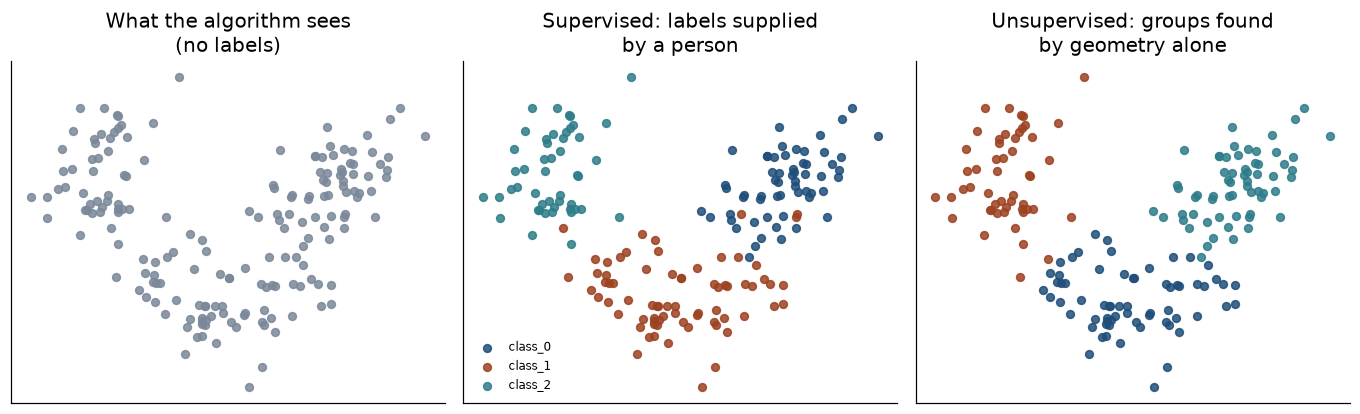

In [6]:
coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.9))
palette = ["#1F4E79", "#9C4221", "#2E7D8A"]

axes[0].scatter(coords[:, 0], coords[:, 1], c="#7A8899", s=26, alpha=.85)
axes[0].set_title("What the algorithm sees\n(no labels)")

for k in range(3):
    m = y == k
    axes[1].scatter(coords[m, 0], coords[m, 1], c=palette[k], s=26, alpha=.85,
                    label=data.target_names[k])
axes[1].set_title("Supervised: labels supplied\nby a person")
axes[1].legend(fontsize=8, frameon=False)

for k in range(3):
    m = clusters == k
    axes[2].scatter(coords[m, 0], coords[m, 1], c=palette[k], s=26, alpha=.85)
axes[2].set_title("Unsupervised: groups found\nby geometry alone")

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIGURES / "kinds_of_learning.png", dpi=150, bbox_inches="tight")
plt.show()

The cluster colours will not match the label colours — k-means numbers its groups
arbitrarily, and there is no reason cluster 0 should be cultivar 0. That arbitrariness
is itself the point: without labels there is nothing to align to.

## 5. Self-supervised learning: the data labels itself

The third case is the interesting one, and the one most often explained badly.

Here nobody supplies labels either — but instead of giving up on a target, we
**manufacture one out of the input**. Hide part of each sample and train the model to
recover it from the rest. The supervision is real; it just costs nothing, because the
answer was in the data all along.

We hide one measurement, `flavanoids`, and predict it from the other twelve.

In [7]:
hidden = "flavanoids"
X_visible = X.drop(columns=[hidden])
y_hidden = X[hidden]

Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    X_visible, y_hidden, test_size=0.3, random_state=RANDOM_STATE
)
pretext = make_pipeline(StandardScaler(), LinearRegression())
pretext.fit(Xs_train, ys_train)
print(f"recovering '{hidden}' from the other measurements: R^2 = {r2_score(ys_test, pretext.predict(Xs_test)):.3f}")

recovering 'flavanoids' from the other measurements: R^2 = 0.816


Mechanically this is the regression from section 3 — the same estimator, the same
call. What changed is **where the target came from**: not from a human annotator, but
from the data itself.

That distinction is what makes the technique matter. A task built this way is called a
*pretext* task: nobody wants a flavanoid predictor. The point is that solving it forces
the model to learn how the measurements relate to one another, and that structure
transfers to tasks you do care about. Scale the idea up — hide a word in a sentence,
hide a patch of an image — and you have the training principle behind most modern
large models, which learn from raw text and images because the supervision costs
nothing to produce.

## 6. The distinction that actually matters

| | Where the target comes from | What it costs | What you can measure |
|---|---|---|---|
| **Supervised** | A person labelled it | Expensive, often the binding constraint | Accuracy against the truth |
| **Unsupervised** | There is no target | Free | Nothing directly — you must judge whether the structure is useful |
| **Self-supervised** | Manufactured from the input | Free | Accuracy on the pretext task, which is not what you want |

Read the middle column. It explains why unsupervised and self-supervised methods
dominate wherever data is abundant and annotation is not, and why supervised learning
still wins whenever someone has already paid for good labels.

Read the right-hand column too, and note the trap: in two of the three cases you
cannot straightforwardly measure whether you have succeeded at the thing you actually
want.

> **Try this:** change `hidden` to another column, such as `proline` or `hue`, and
> rerun section 5. Some measurements are easy to recover from the others and some are
> not. What would a very low R² tell you about that feature's relationship to the
> rest of the table?

## Summary

- The three kinds differ in **where the target comes from**, not in the algorithms.
- Supervised learning needs labels somebody paid for; that cost is usually the real
  constraint on a project.
- Unsupervised learning finds structure with no target, and gives you no direct way to
  check whether that structure means anything.
- Self-supervised learning invents a target out of the input, which is why it scales to
  data nobody has annotated - the principle behind today's large models.